# Hybrid framework V2 - Training

In [10]:
import os
import io
import random
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import dqn_v2
from mylib import tensortools_v2
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[3]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring


Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[15:15:27:241991]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_4.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[15:15:27:452090]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene do

In [12]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

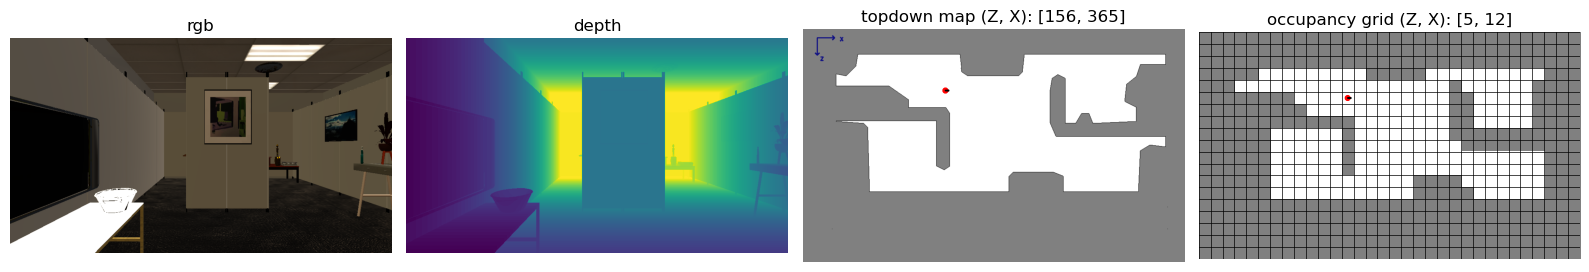

In [13]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb, depth = observations["color_sensor"], observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

In [16]:
# Hyperparameters
gamma = 0.99
epsilon_start = 0.9
epsilon_end = 0.1
epsilon_decay = 100
batch_size = 32
lr = 1e-5
target_update_freq = 100
max_episodes = 300
load_pretrained = True  # Set to False to train from scratch
global_step = 0

# Store losses for debugging
losses = []

# Simulation parameters
NUM_ACTIONS = len(ACTIONS)  # Number of actions available
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform
DISPLAY_STEP = MAX_ITER // 10  # Display every 10% of the actions
DISPLAY_STEP = 1000  # Display every action for debugging

# DQN Network Parameters
PATCH_SIZE = 11  # Patch size for the DQN input

# Initialize DQN + target network
policy_net = dqn_v2.ObjectSearchAgent(num_classes=NUM_CLASSES + 1, num_actions=NUM_ACTIONS, patch_size=PATCH_SIZE)
policy_net = policy_net.to(device)

# Load from file if exists
if load_pretrained and os.path.exists("dqn_policy_v2.pth"):
    policy_net.load_state_dict(torch.load("dqn_policy_v2.pth"))

# Initialize target network based on policy_net
target_net = dqn_v2.ObjectSearchAgent(num_classes=NUM_CLASSES + 1, num_actions=NUM_ACTIONS, patch_size=PATCH_SIZE)
target_net.to(device)  # Move to same device as policy_net
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Set target network to evaluation mode

# Initialize optimizer and replay buffer
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
replay_buffer = dqn_v2.ReplayBuffer(capacity=10_000)

print(f"Replay buffer: {replay_buffer}")

# Epsilon schedule
def get_epsilon(episode):
    return epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / epsilon_decay)

# Track performance
episode_lengths = []
episode_location_errors = []
episode_travelled_distances = []
episode_success_flags = []  
episode_rewards = []

# Main training loop
for episode in tqdm(range(max_episodes)):
    
    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")
    episode_reward = 0.0

    # Last poses buffer
    previous_poses_buffer = []

    # Init agent state
    grid_position = random.choice(grid_free_cells)
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]
    agent_positions = (map_position, grid_position)

    agent_yaw = random.choice([0, 90, 180, 270])
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Set belief map
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Set current state tensors
    pose = tensortools_v2.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
    occ_patch = tensortools_v2.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
    belief_patch = tensortools_v2.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
    target_object_id = tensortools_v2.init_target_id_vector(TARGET_OBJECT_CLASS_ID, num_classes=28)
    state = (pose, occ_patch, belief_patch, target_object_id)

    # Run episode
    while not target_found and num_actions < MAX_ITER:

        # Get epsilon for exploration
        epsilon = get_epsilon(episode)

        # Select action using epsilon-greedy 
        policy_net.eval()  # Set policy network to evaluation mode
        action = dqn_v2.select_action(policy_net, state, epsilon, NUM_ACTIONS)
        action_str = list(ACTIONS)[action]  # Convert action index to action string

        # Perform action if valid
        if simtools.is_action_valid(action_str, grid_position, agent_yaw, grid_free_cells):
            grid_position, agent_yaw = simtools.perform_action(action_str, grid_position, agent_yaw)

        # Update agent position and state
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_positions = (map_position, grid_position)
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)

        # Update metrics
        num_actions += 1
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Update agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
        
        # Initialize processed cells
        processed_cells = []

        # Process the observations
        for det in detections:
            box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
            scale = myutils.compute_bbox_scale(box, rgb)

            # Center of bbox and depth value
            center_x, center_y = simtools.get_box_center(box)
            depth_value = depth[center_y, center_x]

            # Project to real world, grid and map coords
            camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
            object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
            object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

            # Check if projected cell is outside free grid cells
            if object_grid_position in grid_free_cells:
                object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

            # Add this cell to processed cells
            if tuple(object_grid_position) not in processed_cells:
                processed_cells.append(tuple(object_grid_position))

            # Likelihood vector: likelihood of each class (Rule 1)
            likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

            # Kaplan Update to the belief map in that cell
            grid_x, grid_y = object_grid_position
            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Compute every theoretically visible occupied cell
        rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
        visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
        
        # Go through every visible occupied cell and update the belief map
        for cell in visible_occ_cells:
            if tuple(cell) not in processed_cells:
                # Compute distance to the cell
                grid_x, grid_y = cell
                distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                # Compute the likelihood vector for the cell (Rule 2)
                likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                # Kaplan update to the belief map in that cell
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Check if the target object was found in the belief map
        if not target_found:
            target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

        # Compute next state
        next_pose = tensortools_v2.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
        next_occ_patch = tensortools_v2.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
        next_belief_patch = tensortools_v2.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
        next_target_object_id = tensortools_v2.init_target_id_vector(TARGET_OBJECT_CLASS_ID, num_classes=28)
        next_state = (next_pose, next_occ_patch, next_belief_patch, next_target_object_id)

        # Compute reward
        previous_poses_buffer = tensortools_v2.update_previous_poses_buffer(previous_poses_buffer, pose)
        reward = dqn_v2.compute_reward(pose, next_pose, previous_poses_buffer, target_found)

        # #Print current state for debugging
        # print(f"\n\n\nPose: {pose}")
        # print(f"Next pose: {next_pose}")
        # print(f"Previous poses buffer: {previous_poses_buffer}")
        # print(f"\nOccupancy patch: \n{occ_patch}")
        # print(f"Next occupancy patch:\n{next_occ_patch}")

        # print(f"Action: {action_str} (action {action})")
        # print(f"Reward: {reward}")

        # Update previous poses buffer

        # Is it done?
        done = target_found or num_actions >= MAX_ITER

        # Store the transition in the replay buffer
        replay_buffer.push(state, action, reward, next_state, done)

        #print(f"\n\nReplay buffer:\n {replay_buffer[global_step]}\n")

        # Update variables
        pose = next_pose
        occ_patch = next_occ_patch
        belief_patch = next_belief_patch
        target_object_id = next_target_object_id 
        state = next_state
        episode_reward += reward
        global_step += 1

        # Train the policy DQN
        if len(replay_buffer) >= batch_size:
            # Sample and train
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
            poses, occ_patches, belief_patches, goal_ids = states
            next_poses, next_occ_patches, next_belief_patches, next_goal_ids = next_states

            policy_net.train()  # Set policy network to training mode

            # # Print current state and next state for debugging
            # print(f"\n\n\n*****************\nCurrent pose: ", poses[0])
            # print(f"Next pose: ", next_poses[0])

            # print(f"\nCurrent occupancy patches: \n", occ_patches[0])
            # print(f"\nNext occupancy patches: \n", next_occ_patches[0])

            # print(f"\nActions: ", list(ACTIONS)[actions[0]])

            # print(f"\nRewards: ", rewards[0])

            # print(f"\nDones: ", dones[0])


            # Current Q values
            q_values = policy_net(poses, occ_patches, belief_patches, goal_ids)
            state_action_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            # Target Q values
            with torch.no_grad():
                next_q_values = target_net(next_poses, next_occ_patches, next_belief_patches, next_goal_ids)
                max_next_q = next_q_values.max(1)[0]
                expected_q = rewards + (1.0 - dones) * gamma * max_next_q
      
            # Loss and optimization
            loss = torch.nn.functional.mse_loss(state_action_values, expected_q)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
            optimizer.step()

            # Print loss for debugging
            losses.append(loss.item())

        # Update target network
        if global_step % target_update_freq == 0:
            dqn_v2.update_target_network(policy_net, target_net)

    # Compute the target location if it was found
    if target_found:

        if target_grid_position is None: # Not found in the belief map
            # Real world position
            center_x, center_y = simtools.get_box_center(target_bbox)
            depth_value = depth[center_y, center_x]
            target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
        else:
            # Real world position from grid position
            target_location = world_coords[grid_cells.index(target_grid_position)]

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            target_found = False

    # Display simulation result and metrics
    # if target_found:
    #     print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    #     print(f"Found location: {target_location}")
    # else:
    #     print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    # print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    # print(f"Number of actions: {num_actions}")
    # print(f"Travelled distance: {travelled_distance:.2f} m")
    # print(f"Computed location error: {location_error:.3f} m")

    # Append metrics
    episode_lengths.append(num_actions)
    episode_location_errors.append(location_error)
    episode_travelled_distances.append(travelled_distance)
    episode_success_flags.append(target_found)
    episode_rewards.append(episode_reward)

# After training, save the model
torch.save(policy_net.state_dict(), "dqn_policy_v2.pth")

Replay buffer: <mylib.dqn_v2.ReplayBuffer object at 0x7908118780d0>


100%|██████████| 300/300 [1:31:22<00:00, 18.28s/it]


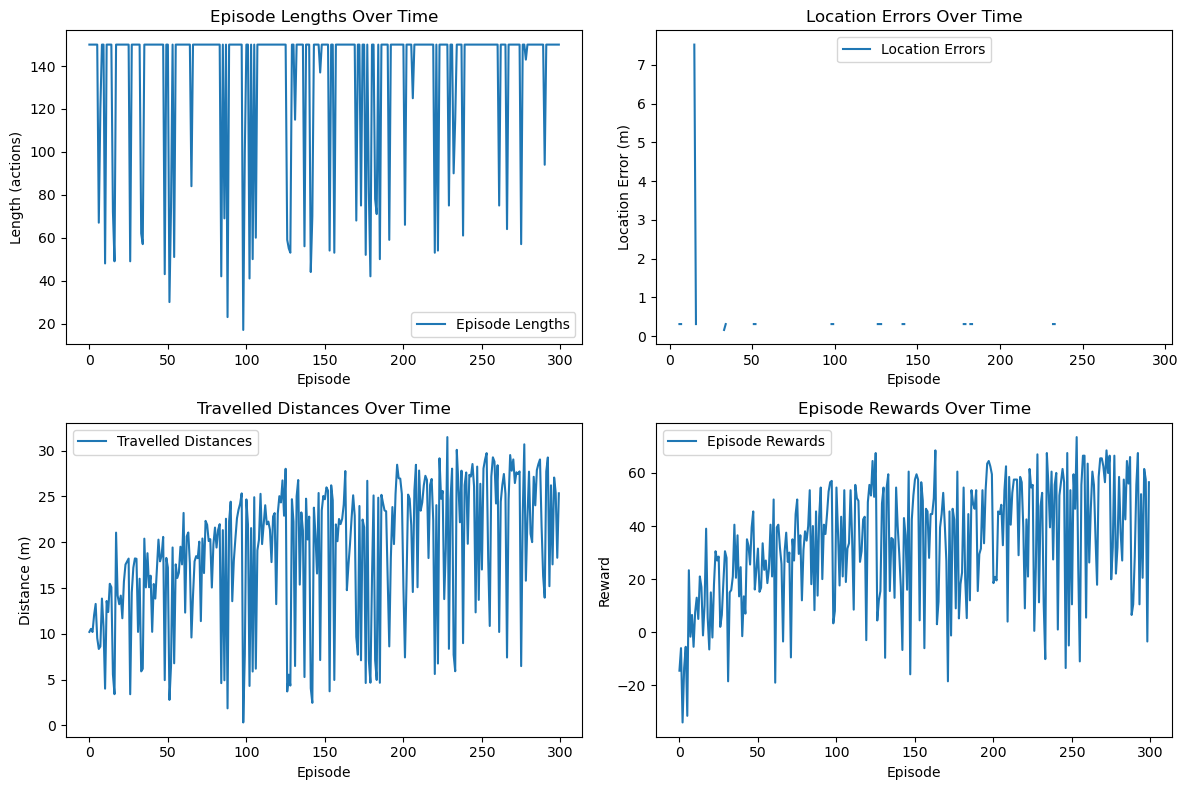

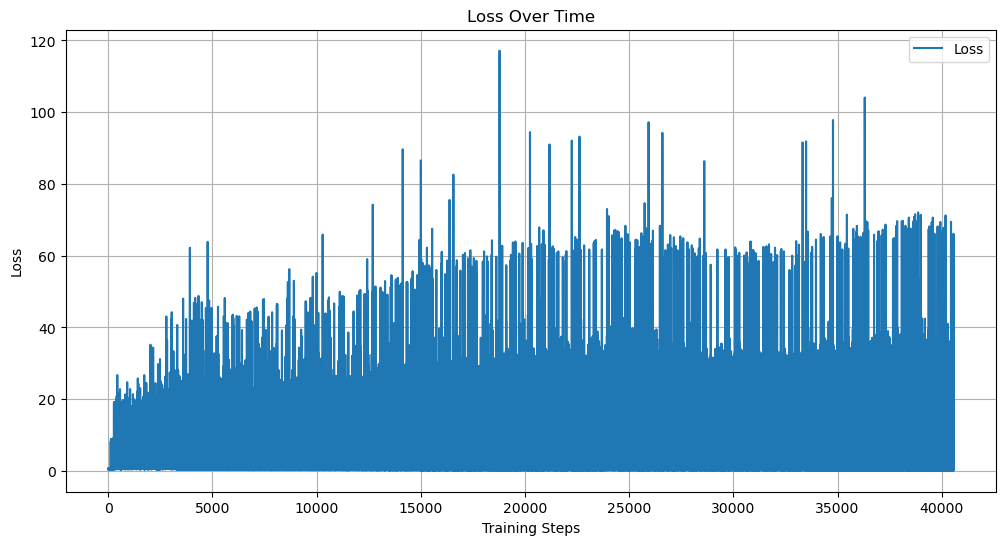

In [17]:
# Plot learning curves
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(episode_lengths, label='Episode Lengths')
plt.xlabel('Episode')
plt.ylabel('Length (actions)')
plt.title('Episode Lengths Over Time')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(episode_location_errors, label='Location Errors')
plt.xlabel('Episode')
plt.ylabel('Location Error (m)')
plt.title('Location Errors Over Time')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(episode_travelled_distances, label='Travelled Distances')
plt.xlabel('Episode')
plt.ylabel('Distance (m)')
plt.title('Travelled Distances Over Time')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episode_rewards, label='Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Episode Rewards Over Time')
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss curve
plt.figure(figsize=(12, 6))
plt.plot(losses, label='Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.legend()
plt.grid()
plt.show()


In [9]:
sim.close()  # Close the simulator